# Pandas and 3D Data

Pandas support 2D data frame where as Numpy support 3D data structure as shown below. In the following example we create a 10 by 10 pixel image, with RGB channel.

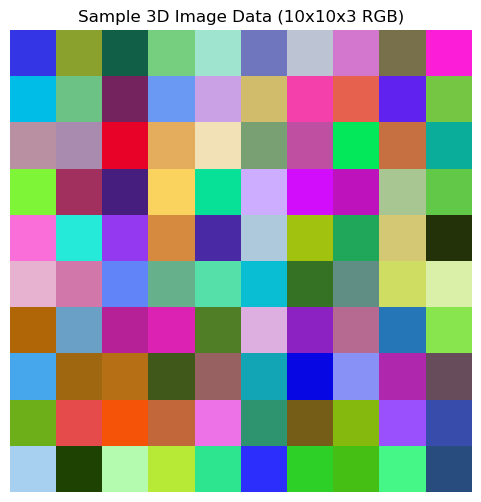

In [1]:
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

# Generate a sample image array (3D: height x width x channels)
image_3d = np.random.randint(0, 256, size=(10, 10, 3), dtype=np.uint8)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image_3d)
plt.title("Sample 3D Image Data (10x10x3 RGB)")
plt.axis('off')
plt.show()

In [2]:
# display the shape and dimensions of the image data as numPy array
print("\nImage shape:", image_3d.shape)
print("Image dimensions:", image_3d.ndim)


Image shape: (10, 10, 3)
Image dimensions: 3


In [3]:
# If we print the entire image data, it will show the pixel values for with a 10, 10, 3 array. the inner arrays is a 10 by 3 array.
print(image_3d)

[[[ 52  53 229]
  [138 162  45]
  [ 18  95  71]
  [118 207 127]
  [159 228 207]
  [112 118 189]
  [188 196 211]
  [210 119 205]
  [120 111  75]
  [251  29 215]]

 [[  0 189 231]
  [108 193 133]
  [117  35  94]
  [105 153 242]
  [202 161 229]
  [209 188 108]
  [244  64 170]
  [230  97  78]
  [ 96  34 238]
  [117 198  67]]

 [[184 144 161]
  [170 139 176]
  [232   2  39]
  [228 173  93]
  [242 225 182]
  [120 160 115]
  [191  79 160]
  [  2 232  90]
  [198 112  65]
  [  9 173 153]]

 [[126 245  55]
  [162  48  95]
  [ 70  30 126]
  [249 211  94]
  [  7 225 152]
  [204 173 255]
  [209  13 252]
  [190  18 188]
  [167 198 145]
  [ 98 200  72]]

 [[249 110 216]
  [ 37 234 217]
  [149  57 240]
  [214 138  64]
  [ 74  41 165]
  [174 201 219]
  [161 195  16]
  [ 32 167  90]
  [213 200 117]
  [ 36  50   9]]

 [[231 178 207]
  [210 119 170]
  [ 97 132 249]
  [102 176 139]
  [ 85 224 170]
  [  9 190 211]
  [ 53 114  36]
  [ 96 142 132]
  [207 222  98]
  [218 240 168]]

 [[176 101   6]
  [106 160 1

```text
Image
 ├── Row 0
 │     ├── Column 0 pixel -> [R,G,B]
 │     ├── Column 1 pixel -> [R,G,B]
 │     └── ...
 │
 ├── Row 1
 │     ├── Column 0 pixel
 │     └── ...
```

In [4]:
print(image_3d.shape)
print(image_3d[0, 0])      # one pixel
print(image_3d[:, :, 0])   # red channel
print(image_3d[:, :, 1])   # green channel
print(image_3d[:, :, 2])   # blue channel

(10, 10, 3)
[ 52  53 229]
[[ 52 138  18 118 159 112 188 210 120 251]
 [  0 108 117 105 202 209 244 230  96 117]
 [184 170 232 228 242 120 191   2 198   9]
 [126 162  70 249   7 204 209 190 167  98]
 [249  37 149 214  74 174 161  32 213  36]
 [231 210  97 102  85   9  53  96 207 218]
 [176 106 183 219  79 221 139 182  37 136]
 [ 71 159 183  64 151  17   7 136 175 103]
 [109 229 245 193 237  46 117 133 155  56]
 [167  30 181 183  44  44  45  70  69  40]]
[[ 53 162  95 207 228 118 196 119 111  29]
 [189 193  35 153 161 188  64  97  34 198]
 [144 139   2 173 225 160  79 232 112 173]
 [245  48  30 211 225 173  13  18 198 200]
 [110 234  57 138  41 201 195 167 200  50]
 [178 119 132 176 224 190 114 142 222 240]
 [101 160  33  34 126 175  34 106 118 229]
 [167 103 111  89  97 165   7 145  39  77]
 [175  75  84 103 113 148  93 185  80  76]
 [208  66 251 234 229  46 208 191 247  76]]
[[229  45  71 127 207 189 211 205  75 215]
 [231 133  94 242 229 108 170  78 238  67]
 [161 176  39  93 182 115 

In [5]:
# Convert to DataFrame for analysis
image_flat = image_3d.reshape(-1, 3)
image_df = pd.DataFrame(image_flat, columns=['R', 'G', 'B'])
print("Image data as DataFrame:")
print(image_df)

Image data as DataFrame:
      R    G    B
0    52   53  229
1   138  162   45
2    18   95   71
3   118  207  127
4   159  228  207
..  ...  ...  ...
95   44   46  251
96   45  208   38
97   70  191   20
98   69  247  134
99   40   76  126

[100 rows x 3 columns]


In [6]:
# display the shape and dimensions of the image data from image_df
print("\nDataFrame shape:", image_df.shape)
print("DataFrame dimensions:", image_df.ndim)


DataFrame shape: (100, 3)
DataFrame dimensions: 2


NumPy stores the image with a true 3D shape: height × width × color channels. When we reshape that array and load it into a DataFrame, each row becomes one pixel and each column becomes one color channel, so Pandas represents the data as a 2D table.

A DataFrame is fundamentally 2-dimensional:

- rows
- columns

The third dimension in this case is encoded inside the values for each row, rather than in the DataFrame’s axes.

## Multi-Index in Pandas

Pandas can mimic higher-dimensional structure using MultiIndex, but the underlying object is still a 2D DataFrame.

The following is an exmaple on how we convert a normal spreadsheet data in csv into a panel format.

In [7]:
# Read csv file with pandas
raw_df = pd.read_csv("sales.csv")
raw_df

,Store,Quarter,Sales_2024,Sales_2025,Profit_2024,Profit_2025,Expenses_2024,Expenses_2025
0,Store A,Q1,67,184,158,52,194,145
1,Store A,Q2,93,132,149,66,111,104
2,Store A,Q3,65,158,150,114,116,81
3,Store A,Q4,188,58,123,149,109,189
4,Store B,Q1,167,90,63,108,147,171
5,Store B,Q2,50,73,176,132,156,127
6,Store B,Q3,85,135,75,93,115,85
7,Store B,Q4,73,143,173,70,53,93
8,Store C,Q1,160,66,94,64,179,175
9,Store C,Q2,142,152,158,189,175,82


### Why Convert from Wide Form to Long Form?

Converting data from wide form to long form is essential for:

1. **Analysis Flexibility**: Long-form data is easier to filter, group, and aggregate, especially when working with libraries like Pandas.
2. **Visualization**: Many plotting libraries, such as Seaborn and Plotly, expect data in long form for creating advanced visualizations.
3. **Compatibility**: Long-form data aligns with the "tidy data" principles, making it compatible with a wide range of data analysis tools.

In the next cell, we demonstrate how to reshape the panel data for specific analysis tasks.

https://towardsdatascience.com/reshaping-a-pandas-dataframe-long-to-wide-and-vice-versa-517c7f0995ad/

https://pandas.pydata.org/docs/reference/api/pandas.wide_to_long.html

In [9]:
# Load CSV
raw_df = pd.read_csv("sales.csv")

# Convert wide format to panel (long) format
panel_df = pd.wide_to_long(
    raw_df,
    stubnames=['Sales', 'Profit', 'Expenses'],
    i=['Store', 'Quarter'],
    j='Year',
    sep='_',
    suffix='\\d+'
).reset_index()

print(panel_df)

      Store Quarter  Year  Sales  Profit  Expenses
0   Store A      Q1  2024     67     158       194
1   Store A      Q1  2025    184      52       145
2   Store A      Q2  2024     93     149       111
3   Store A      Q2  2025    132      66       104
4   Store A      Q3  2024     65     150       116
5   Store A      Q3  2025    158     114        81
6   Store A      Q4  2024    188     123       109
7   Store A      Q4  2025     58     149       189
8   Store B      Q1  2024    167      63       147
9   Store B      Q1  2025     90     108       171
10  Store B      Q2  2024     50     176       156
11  Store B      Q2  2025     73     132       127
12  Store B      Q3  2024     85      75       115
13  Store B      Q3  2025    135      93        85
14  Store B      Q4  2024     73     173        53
15  Store B      Q4  2025    143      70        93
16  Store C      Q1  2024    160      94       179
17  Store C      Q1  2025     66      64       175
18  Store C      Q2  2024    14

### Using MultiIndex to Simulate 3D Data

Pandas uses MultiIndex to represent higher-dimensional data in a 2D DataFrame. For example:

1. **Rows and Columns as Axes**:
   - The row MultiIndex (`Store`, `Quarter`) represents one axis.
   - The column MultiIndex (`Metric`, `Year`) represents another axis.

2. **Simulating a Third Dimension**:
   - The combination of row and column MultiIndex levels allows you to access data as if it were stored in a 3D structure.
   - For example, you can slice data for a specific `Store` and `Year` to get all metrics for all quarters.

This approach keeps the data in a tabular format while enabling operations that mimic 3D data manipulation.

In [10]:
multi_df = panel_df.pivot(
    index=['Store', 'Quarter'],
    columns='Year',
    values=['Sales', 'Profit', 'Expenses']
)

multi_df

Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122

#### Explanation of the Code

The code snippet reshapes the `panel_df` DataFrame using the `pivot` method:

```python
multi_df = panel_df.pivot(
    index=['Store', 'Quarter'],
    columns='Year',
    values=['Sales', 'Profit', 'Expenses']
)
```

##### What It Does:
1. **`index=['Store', 'Quarter']`**: Specifies the row labels for the resulting DataFrame. Each unique combination of `Store` and `Quarter` becomes a row.
2. **`columns='Year'`**: Specifies the column labels. Each unique value in the `Year` column becomes a column level.
3. **`values=['Sales', 'Profit', 'Expenses']`**: Specifies the data to populate the table. The values for `Sales`, `Profit`, and `Expenses` are distributed across the new columns.

##### Result:
- The resulting `multi_df` has a MultiIndex on the columns, with levels for `Year` and the metrics (`Sales`, `Profit`, `Expenses`).
- This structure allows for easier slicing and analysis of data across different dimensions.


https://pandas.pydata.org/docs/reference/api/pandas.pivot.html#pandas.pivot

### Examples of Slicing

In [11]:
print("Show complete multi-index DataFrame:")
multi_df

Show complete multi-index DataFrame:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122

In [12]:
# Example 1: Select data for a specific store using .loc
print("Sales data for Store A:")
multi_df.loc['Store A']

Sales data for Store A:


Sales      Profit      Expenses     
Year     2024 2025   2024 2025     2024 2025
Quarter                                     
Q1         67  184    158   52      194  145
Q2         93  132    149   66      111  104
Q3         65  158    150  114      116   81
Q4        188   58    123  149      109  189

In [13]:
# Example 2: Select data for a specific quarter across all stores
print("\nQ1 data for all stores:")
multi_df.xs('Q1', level='Quarter')


Q1 data for all stores:


Sales      Profit      Expenses     
Year     2024 2025   2024 2025     2024 2025
Store                                       
Store A    67  184    158   52      194  145
Store B   167   90     63  108      147  171
Store C   160   66     94   64      179  175

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.xs.html

In [14]:
# Example 3: Select specific metric and year combination
print("\nSales for 2024 across all stores and quarters:")
print(multi_df.loc[:, ('Sales', 2024)])


Sales for 2024 across all stores and quarters:
Store    Quarter
Store A  Q1          67
         Q2          93
         Q3          65
         Q4         188
Store B  Q1         167
         Q2          50
         Q3          85
         Q4          73
Store C  Q1         160
         Q2         142
         Q3          55
         Q4          77
Name: (Sales, 2024), dtype: int64


In [15]:
# Example 4: Slice within a single store across quarters
print("\nQ1 to Q3 data for Store A:")
multi_df.loc[('Store A', slice('Q1', 'Q3')), :]


Q1 to Q3 data for Store A:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81

### Why Pandas Doesn't Support True 3D DataFrames

Pandas was designed primarily for 2D tabular data analysis, similar to spreadsheets or SQL tables. Adding true 3D support would complicate the API and make operations more complex. Instead, Pandas uses MultiIndex to represent higher-dimensional data when needed, keeping the core DataFrame as a simple 2D structure.

For example, in our image data:

- Each row represents one pixel from the original 3D array
- The columns represent the RGB color channels
- The spatial position (height, width) is lost in the flattening process
- To preserve spatial information, you'd need to add columns for pixel coordinates or use a MultiIndex with height/width levels.

In [16]:
# Example: Show how the first few pixels map from 3D array to DataFrame
print("First 5 pixels from original 3D array:")
print("Pixel (0,0):", image_3d[0, 0])  # RGB values for top-left pixel
print("Pixel (0,1):", image_3d[0, 1])  # RGB values for next pixel
print("Pixel (0,2):", image_3d[0, 2])  # RGB values for next pixel
print("Pixel (0,3):", image_3d[0, 3])  # RGB values for next pixel
print("Pixel (0,4):", image_3d[0, 4])  # RGB values for next pixel

print("\nSame pixels in DataFrame (first 5 rows):")
print(image_df.head())

First 5 pixels from original 3D array:
Pixel (0,0): [ 52  53 229]
Pixel (0,1): [138 162  45]
Pixel (0,2): [18 95 71]
Pixel (0,3): [118 207 127]
Pixel (0,4): [159 228 207]

Same pixels in DataFrame (first 5 rows):
     R    G    B
0   52   53  229
1  138  162   45
2   18   95   71
3  118  207  127
4  159  228  207


## Pandas Panel: Historical Context

- Panel was a 3D data structure (items × major_axis × minor_axis)
- It was deprecated in Pandas 0.20.0 (May 2017) and removed in Pandas 0.25.0 (September 2019)

- Example of what Panel looked like (historical):
- panel = pd.Panel(data, items=['A', 'B'], major_axis=dates, minor_axis=columns)

Why it was dropped:
1. Limited use cases - most users didn't need true 3D data structures
2. Inconsistent API - harder to maintain compared to DataFrame
3. MultiIndex is more flexible - can represent N-dimensional data efficiently
4. Performance issues - Panel operations were slower than DataFrame operations
5. Simplicity - keeping Pandas focused on 2D DataFrames made the library cleaner


In [17]:
# Modern approach: Use MultiIndex instead of Panel
# Our multi_df uses MultiIndex on both rows and columns to achieve panel-like functionality
print("Modern Panel-like structure using MultiIndex:")
display(multi_df)
print("\nThis achieves the same 3D representation without a dedicated Panel class")

Modern Panel-like structure using MultiIndex:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122


This achieves the same 3D representation without a dedicated Panel class
